# Quantitative Analysis: S&P 500 vs FTSE 100

This project compares the historical performance and risk of the S&P 500 and FTSE 100 using Python.

The analysis examines:
- Returns  
- Volatility  
- Correlation
- Cumulative performance 
Data source: Yahoo Finance, downloaded using yfinance. The requested period is 12 September 2016 to 10 September 2026.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
sp500 = "^GSPC"
ftse100 = "^FTSE"

In [3]:
sp500_data = yf.download(
    sp500,
    start="2016-09-12",
    end="2026-09-11",  # The end date is excluded from the download.
    interval="1d"
)

[*********************100%***********************]  1 of 1 completed


In [4]:
ftse_data = yf.download(
    ftse100,
    start="2016-09-12",
    end="2026-09-11",  # The end date is excluded from the download.
    interval="1d"
)

[*********************100%***********************]  1 of 1 completed


In [5]:
sp500_data.head()
ftse_data.head()

Price,Close,High,Low,Open,Volume
Ticker,^FTSE,^FTSE,^FTSE,^FTSE,^FTSE
Date,,,,,
2016-09-12,6700.899902,6777.000000,6654.500000,6777.000000,861327100
2016-09-13,6665.600098,6724.700195,6665.600098,6700.899902,839927300
2016-09-14,6673.299805,6720.299805,6665.600098,6665.600098,676448700
2016-09-15,6730.299805,6736.799805,6654.799805,6673.299805,747305800
2016-09-16,6710.299805,6746.299805,6692.700195,6730.299805,1346126200


In [6]:
sp500_close = sp500_data["Close"]
ftse_close = ftse_data["Close"]

In [7]:
prices = pd.concat(
    [sp500_close, ftse_close], 
     axis=1, 
     join="inner"
)
prices.head()

Ticker,^GSPC,^FTSE
Date,,
2016-09-12,2159.040039,6700.899902
2016-09-13,2127.020020,6665.600098
2016-09-14,2125.770020,6673.299805
2016-09-15,2147.260010,6730.299805
2016-09-16,2139.159912,6710.299805


In [8]:
prices.columns = ["S&P 500", "FTSE 100"] 
# Keep only dates with a closing price for both indices.
prices = prices.dropna()
prices.head()

,S&P 500,FTSE 100
Date,,
2016-09-12,2159.040039,6700.899902
2016-09-13,2127.020020,6665.600098
2016-09-14,2125.770020,6673.299805
2016-09-15,2147.260010,6730.299805
2016-09-16,2139.159912,6710.299805


In [9]:
sp500_returns = sp500_close.pct_change()
ftse_returns = ftse_close.pct_change()

daily_returns = pd.concat(
    [sp500_returns, ftse_returns],
    axis=1,
    join="inner"
)

daily_returns.columns = ["S&P 500", "FTSE 100"]
daily_returns = daily_returns.dropna()

In [10]:
daily_returns.head()

,S&P 500,FTSE 100
Date,,
2016-09-13,-0.014831,-0.005268
2016-09-14,-0.000588,0.001155
2016-09-15,0.010109,0.008542
2016-09-16,-0.003772,-0.002972
2016-09-19,-0.000019,0.015394


In [11]:
sp500_adr = daily_returns["S&P 500"].mean() 
ftse_adr = daily_returns["FTSE 100"].mean() 
print("S&P 500 Average Daily Return:", round(sp500_adr * 100, 4), "%")
print("FTSE 100 Average Daily Return:", round(ftse_adr * 100, 4), "%")

S&P 500 Average Daily Return: 0.0537 %
FTSE 100 Average Daily Return: 0.0207 %


In [12]:
sp500_std = daily_returns["S&P 500"].std()
ftse_std = daily_returns["FTSE 100"].std()
print("S&P 500 Daily Volatility:", round(sp500_std * 100, 4), "%")
print("FTSE 100 Daily Volatility:", round(ftse_std * 100, 4), "%")

S&P 500 Daily Volatility: 1.1393 %
FTSE 100 Daily Volatility: 0.9334 %


In [13]:
sp500_annual_vol = sp500_std * np.sqrt(252)
ftse_annual_vol = ftse_std * np.sqrt(252) 

In [14]:
print("S&P 500 Annual Volatility:", round(sp500_annual_vol * 100, 4), "%")
print("FTSE 100 Annual Volatility:", round(ftse_annual_vol * 100, 4), "%")

S&P 500 Annual Volatility: 18.0859 %
FTSE 100 Annual Volatility: 14.8177 %


In [15]:
# Use the shared dates so both indices start and finish together.
sp500_growth = prices["S&P 500"] / prices["S&P 500"].iloc[0]
ftse_growth = prices["FTSE 100"] / prices["FTSE 100"].iloc[0]

In [16]:
cumulative_growth = pd.concat(
    [sp500_growth, ftse_growth],
    axis=1
)

cumulative_growth.columns = ["S&P 500", "FTSE 100"]

In [17]:
cumulative_growth.tail()

,S&P 500,FTSE 100
Date,,
2026-09-03,3.588498,1.616425
2026-09-04,3.575015,1.616365
2026-09-08,3.554135,1.613470
2026-09-09,3.536924,1.592338
2026-09-10,3.516239,1.583205


In [18]:
correlation = daily_returns["S&P 500"].corr(daily_returns["FTSE 100"])

print("S&P 500 and FTSE 100 Correlation:", round(correlation, 3))

S&P 500 and FTSE 100 Correlation: 0.488


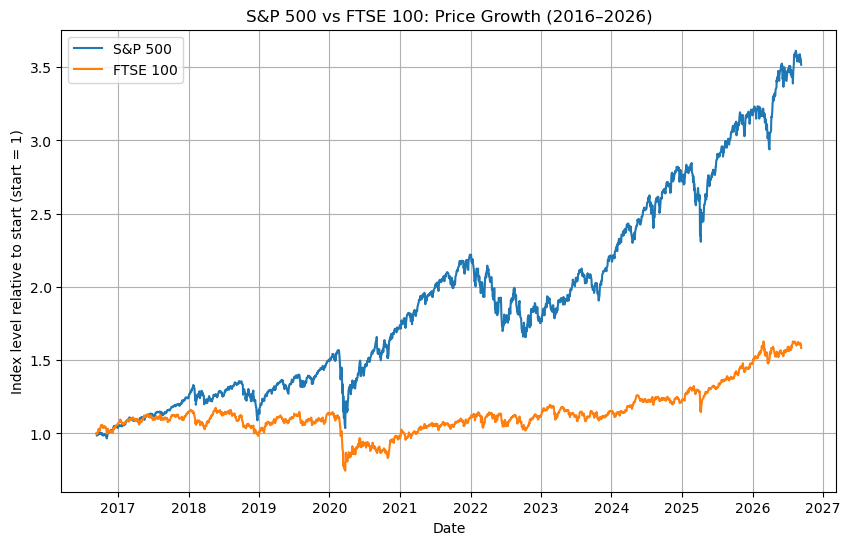

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(cumulative_growth.index, cumulative_growth["S&P 500"], label="S&P 500")
plt.plot(cumulative_growth.index, cumulative_growth["FTSE 100"], label="FTSE 100")

plt.title("S&P 500 vs FTSE 100: Price Growth (2016–2026)")
plt.xlabel("Date")
plt.ylabel("Index level relative to start (start = 1)")
plt.legend()
plt.grid(True)

plt.show()

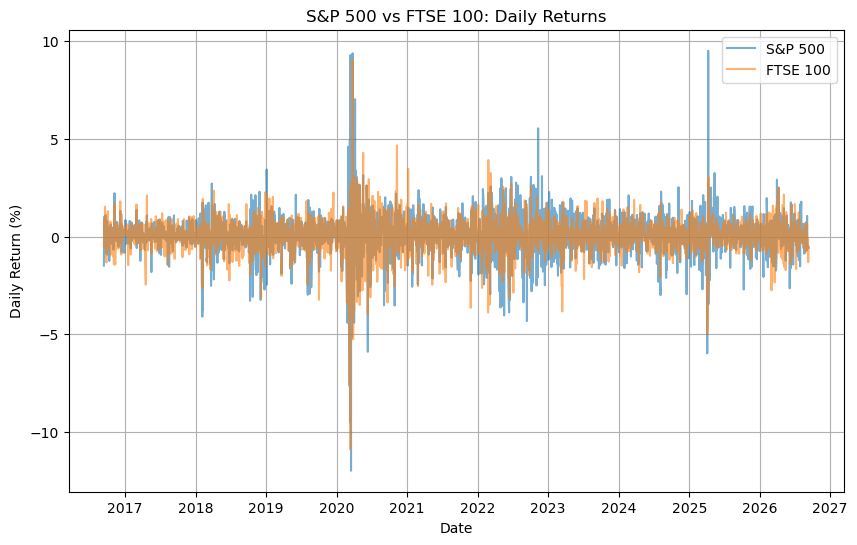

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(daily_returns.index, daily_returns["S&P 500"] * 100, label="S&P 500", alpha=0.6)
plt.plot(daily_returns.index, daily_returns["FTSE 100"] * 100, label="FTSE 100", alpha=0.6)

plt.title("S&P 500 vs FTSE 100: Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.legend()
plt.grid(True)

plt.show()

## Conclusion

Over the 10-year period analysed, the S&P 500 produced a higher average daily return and substantially greater price growth than the FTSE 100. However, the S&P 500 also experienced greater volatility, with annualised volatility of approximately 18.1% compared with 14.8% for the FTSE 100.

The daily returns of the two indices had a moderate positive correlation of approximately 0.49, showing that the US and UK markets often moved in the same direction but were not perfectly aligned.

In this sample, the S&P 500 had both higher price growth and higher volatility.

This analysis uses price-index data and therefore does not include reinvested dividends.

The comparison does not convert returns into a common currency. US and UK market holidays and closing times differ, so returns matched by date do not always cover exactly the same interval.
